# 21 · Evaluando Modelos de Clasificación (*Evaluating Classification Models*)

En el notebook anterior entrenamos una **Regresión Logística** con 91.1 % de accuracy. ¿Pero es bueno ese número?

- Si **siempre** predijéramos *"paid off"* (la clase mayoritaria), acertaríamos el ~55 % de las veces *sin modelo*.
- ¿Qué **tipo** de errores comete el modelo? ¿Deja pasar *defaults* o rechaza *paid-offs*?

En este notebook aprendemos el kit completo de evaluación:

$$\text{modelo} \;\xrightarrow{\text{predict\_proba}}\; \text{probabilidades} \;\xrightarrow{\text{cutoff}}\; \text{clases predichas} \;\xrightarrow{\text{métricas}}\; \text{¿qué tan bueno es?}$$

## 0 · Datos y modelos (*Setup*)

Cargamos `loans.csv`, hacemos **train/test split** (primera vez en clasificación) y entrenamos dos modelos: Regresión Logística y LDA.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
)

df = pd.read_csv("../data/loans.csv")
PREDICTORS = ["borrower_score", "payment_inc_ratio"]
TARGET = "outcome"
CLASSES = ["default", "paid off"]  # default=0, paid off=1

enc_y = OrdinalEncoder(categories=[CLASSES])
df["outcome_num"] = enc_y.fit_transform(df[[TARGET]]).ravel().astype(int)

X = df[PREDICTORS].to_numpy()
y = df["outcome_num"].to_numpy()
rng = np.random.default_rng(42)

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Entrenar modelos
lr = LogisticRegression()
lr.fit(X_train, y_train)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Predicciones
y_pred_lr = lr.predict(X_test)
y_pred_lda = lda.predict(X_test)

# Probabilidades
y_proba_lr = lr.predict_proba(X_test)[:, 1]  # P(paid off)
y_proba_lda = lda.predict_proba(X_test)[:, 1]

print(f"Train: {len(X_train)} filas  |  Test: {len(X_test)} filas")
print(
    f"\nDistribución en train:  default={np.sum(y_train == 0)}, paid off={np.sum(y_train == 1)}"
)
print(
    f"Distribución en test:   default={np.sum(y_test == 0)}, paid off={np.sum(y_test == 1)}"
)
print(f"Prevalencia paid off:   {y_test.mean():.1%}")

Train: 2250 filas  |  Test: 750 filas

Distribución en train:  default=1012, paid off=1238
Distribución en test:   default=338, paid off=412
Prevalencia paid off:   54.9%


## 1 · Exactitud y sus límites (*Accuracy*)

La métrica más simple:

$$\text{Accuracy} = \frac{TP + TN}{N}$$

Pero **accuracy sola engaña**. Un modelo que siempre diga *"paid off"* ya acierta el ~55 %. Veamos qué tan lejos llegan nuestros modelos vs. esa baseline naive.

Accuracy Logistic Regression: 92.5%
Accuracy LDA:                 91.2%
Baseline naive (siempre 'paid off'): 54.9%


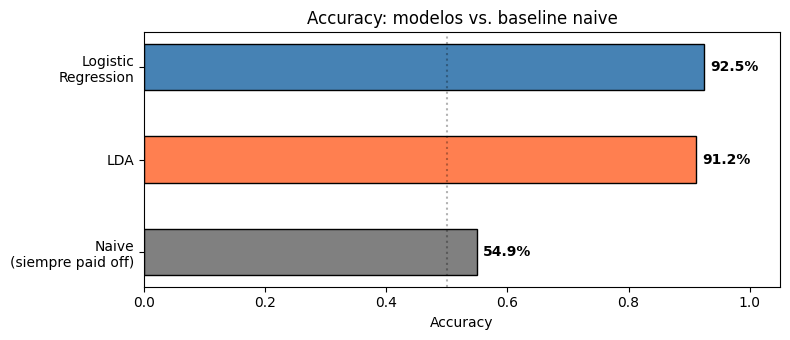


→ Ambos modelos superan ampliamente la baseline
→ Pero accuracy NO dice qué tipo de errores cometen


In [4]:
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_lda = accuracy_score(y_test, y_pred_lda)
acc_naive = y_test.mean()  # siempre predecir la clase mayoritaria

print(f"Accuracy Logistic Regression: {acc_lr:.1%}")
print(f"Accuracy LDA:                 {acc_lda:.1%}")
print(f"Baseline naive (siempre 'paid off'): {acc_naive:.1%}")

fig, ax = plt.subplots(figsize=(8, 3.5))
models = ["Naive\n(siempre paid off)", "LDA", "Logistic\nRegression"]
accs = [acc_naive, acc_lda, acc_lr]
colors = ["gray", "coral", "steelblue"]
bars = ax.barh(models, accs, color=colors, edgecolor="k", height=0.5)
for bar, acc in zip(bars, accs):
    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{acc:.1%}",
        va="center",
        fontweight="bold",
    )
ax.set_xlim(0, 1.05)
ax.set_xlabel("Accuracy")
ax.set_title("Accuracy: modelos vs. baseline naive")
ax.axvline(0.5, color="k", linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n→ Ambos modelos superan ampliamente la baseline")
print("→ Pero accuracy NO dice qué tipo de errores cometen")

## 2 · Matriz de confusión (*Confusion Matrix*)

La tabla 2×2 que desglosa **todos** los aciertos y errores:

|  | Predicho: default | Predicho: paid off |
|:--|:-:|:-:|
| **Real: default** | TN ✓ | FP ✗ |
| **Real: paid off** | FN ✗ | TP ✓ |

- **TP** (*True Positive*): predicho paid off, realmente paid off
- **TN** (*True Negative*): predicho default, realmente default
- **FP** (*False Positive*): predicho paid off, realmente default — *¡aprobamos un mal préstamo!*
- **FN** (*False Negative*): predicho default, realmente paid off — *rechazamos un buen préstamo*

In [20]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp = cm_lr.ravel()

print("Matriz de confusión — Logistic Regression")
print(f"              Pred default  Pred paid off")
print(f"Real default       {tn:>4} (TN)      {fp:>4} (FP)")
print(f"Real paid off      {fn:>4} (FN)      {tp:>4} (TP)")
print(f"\nTotal test: {len(y_test)}")
print(f"Correctos:  {tn + tp}  |  Errores: {fp + fn}")

Matriz de confusión — Logistic Regression
              Pred default  Pred paid off
Real default        304 (TN)        34 (FP)
Real paid off        22 (FN)       390 (TP)

Total test: 750
Correctos:  694  |  Errores: 56


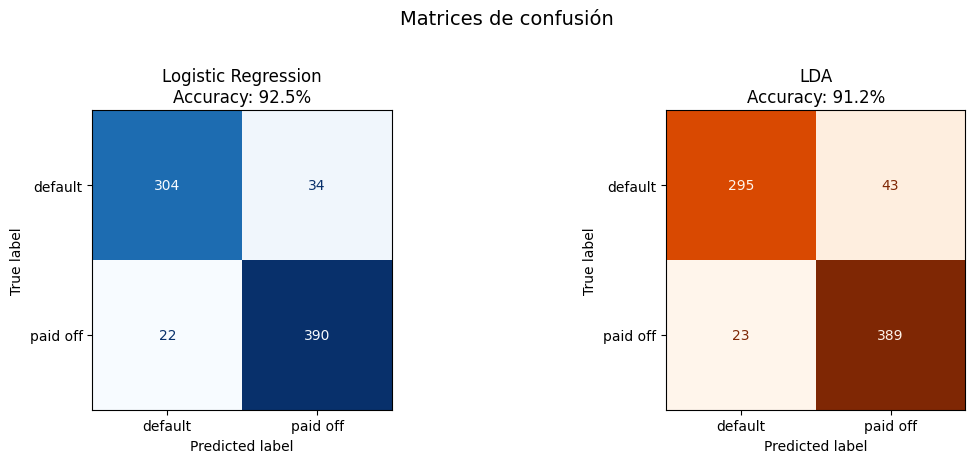

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, y_pred, name, color in [
    (axes[0], y_pred_lr, "Logistic Regression", "Blues"),
    (axes[1], y_pred_lda, "LDA", "Oranges"),
]:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
    disp.plot(ax=ax, cmap=color, colorbar=False)
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f"{name}\nAccuracy: {acc:.1%}", fontsize=12)

plt.suptitle("Matrices de confusión", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3 · Precisión, Sensibilidad y Especificidad (*Precision, Recall, Specificity*)

Tres métricas derivadas de la matriz de confusión, cada una responde una pregunta diferente:

| Métrica | Fórmula | Pregunta |
|:--|:-:|:--|
| **Recall** (*Sensitivity*) | $\frac{TP}{TP + FN}$ | De los *paid off* reales, ¿cuántos capturé? |
| **Specificity** | $\frac{TN}{TN + FP}$ | De los *default* reales, ¿cuántos identifiqué? |
| **Precision** | $\frac{TP}{TP + FP}$ | De los que predije *paid off*, ¿cuántos realmente lo son? |

En préstamos: un banco puede priorizar **specificity** (rechazar defaults) incluso si rechaza algunos buenos préstamos.

In [21]:
# Cálculo manual — Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp = cm_lr.ravel()

recall_manual = tp / (tp + fn)
specificity_manual = tn / (tn + fp)
precision_manual = tp / (tp + fp)

print("=== Cálculo manual (Logistic Regression) ===")
print(f"Recall (Sensitivity) = TP/(TP+FN) = {tp}/({tp}+{fn}) = {recall_manual:.4f}")
print(
    f"Specificity          = TN/(TN+FP) = {tn}/({tn}+{fp}) = {specificity_manual:.4f}"
)
print(f"Precision            = TP/(TP+FP) = {tp}/({tp}+{fp}) = {precision_manual:.4f}")

# Verificar con sklearn
print(f"\n=== Verificación sklearn ===")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")

=== Cálculo manual (Logistic Regression) ===
Recall (Sensitivity) = TP/(TP+FN) = 390/(390+22) = 0.9466
Specificity          = TN/(TN+FP) = 304/(304+34) = 0.8994
Precision            = TP/(TP+FP) = 390/(390+34) = 0.9198

=== Verificación sklearn ===
Recall:    0.9466
Precision: 0.9198


In [9]:
# Tabla comparativa
def compute_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Specificity": tn / (tn + fp),
    }


metrics_lr = compute_metrics(y_test, y_pred_lr)
metrics_lda = compute_metrics(y_test, y_pred_lda)

comparison = pd.DataFrame({"Logistic Regression": metrics_lr, "LDA": metrics_lda}).T
print(comparison.to_string(float_format=lambda x: f"{x:.3f}"))

print("\n→ Recall alto = capturamos muchos paid-off reales")
print("→ Specificity alto = identificamos muchos defaults reales")
print("→ Un banco priorizaría specificity para evitar aprobar préstamos riesgosos")

                     Accuracy  Precision  Recall  Specificity
Logistic Regression     0.925      0.920   0.947        0.899
LDA                     0.912      0.900   0.944        0.873

→ Recall alto = capturamos muchos paid-off reales
→ Specificity alto = identificamos muchos defaults reales
→ Un banco priorizaría specificity para evitar aprobar préstamos riesgosos


## 4 · F1 Score — media armónica (*Harmonic Mean*)

F1 combina precision y recall en un solo número:

$$F_1 = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

¿Por qué media **armónica** y no aritmética? Porque penaliza los extremos:

| Precision | Recall | Media aritmética | Media armónica (F1) |
|:-:|:-:|:-:|:-:|
| 0.99 | 0.01 | 0.50 | **0.02** |
| 0.80 | 0.80 | 0.80 | **0.80** |

Si una de las dos es muy baja, F1 lo refleja.

Precision: 0.9198
Recall:    0.9466
F1 manual: 2 × 0.9198 × 0.9466 / (0.9198 + 0.9466) = 0.9330
F1 sklearn: 0.9330


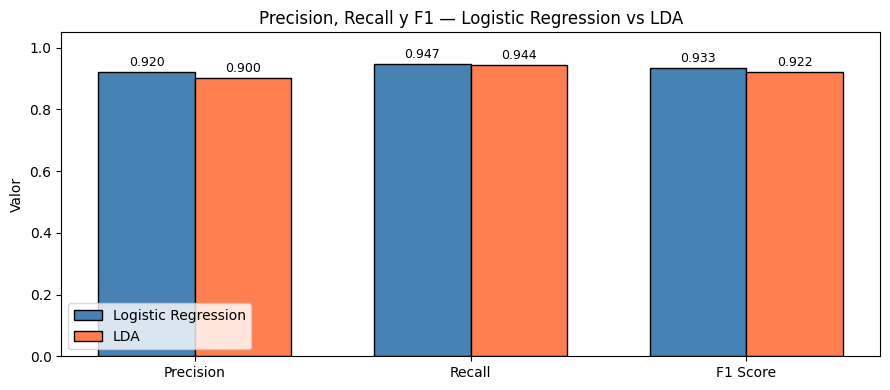

In [23]:
# Cálculo manual
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_manual = 2 * prec_lr * rec_lr / (prec_lr + rec_lr)

print(f"Precision: {prec_lr:.4f}")
print(f"Recall:    {rec_lr:.4f}")
print(
    f"F1 manual: 2 × {prec_lr:.4f} × {rec_lr:.4f} / ({prec_lr:.4f} + {rec_lr:.4f}) = {f1_manual:.4f}"
)
print(f"F1 sklearn: {f1_score(y_test, y_pred_lr):.4f}")

# Comparación visual
fig, ax = plt.subplots(figsize=(9, 4))
x_pos = np.arange(3)
width = 0.35

vals_lr = np.array([prec_lr, rec_lr, f1_score(y_test, y_pred_lr)])
vals_lda = np.array(
    [
        precision_score(y_test, y_pred_lda),
        recall_score(y_test, y_pred_lda),
        f1_score(y_test, y_pred_lda),
    ]
)

ax.bar(
    x_pos - width / 2,
    vals_lr,
    width,
    label="Logistic Regression",
    color="steelblue",
    edgecolor="k",
)
ax.bar(x_pos + width / 2, vals_lda, width, label="LDA", color="coral", edgecolor="k")

ax.set_xticks(x_pos)
ax.set_xticklabels(["Precision", "Recall", "F1 Score"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Valor")
ax.set_title("Precision, Recall y F1 — Logistic Regression vs LDA")
ax.legend()

for i, (v1, v2) in enumerate(zip(vals_lr, vals_lda)):
    ax.text(i - width / 2, v1 + 0.02, f"{v1:.3f}", ha="center", fontsize=9)
    ax.text(i + width / 2, v2 + 0.02, f"{v2:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 5 · El umbral de corte (*Cutoff Threshold*)

Hasta ahora usamos **cutoff = 0.5** (por defecto). Pero el cutoff es una **decisión de negocio**:

- Bajar el cutoff → más *paid off* predichos → **sube recall**, baja specificity
- Subir el cutoff → más *default* predichos → **sube specificity**, baja recall

El libro menciona que un cutoff alternativo es la **prevalencia** de la clase positiva en los datos.

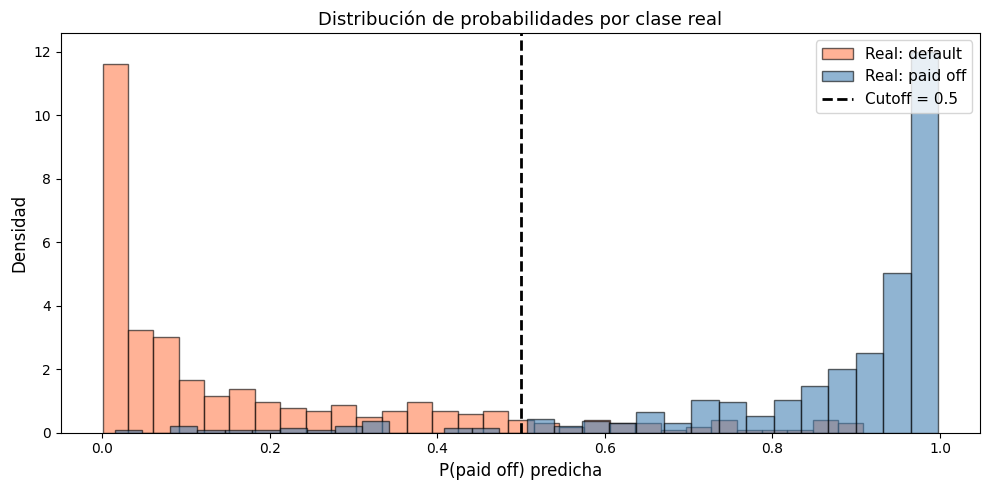

→ A la izquierda del cutoff: predichos como default
→ A la derecha del cutoff: predichos como paid off
→ La zona de solapamiento es donde el modelo duda


In [24]:
# Distribución de probabilidades por clase real
fig, ax = plt.subplots(figsize=(10, 5))

mask_default = y_test == 0
mask_paid = y_test == 1

ax.hist(
    y_proba_lr[mask_default],
    bins=30,
    alpha=0.6,
    color="coral",
    label="Real: default",
    edgecolor="k",
    density=True,
)
ax.hist(
    y_proba_lr[mask_paid],
    bins=30,
    alpha=0.6,
    color="steelblue",
    label="Real: paid off",
    edgecolor="k",
    density=True,
)

ax.axvline(0.5, color="k", linestyle="--", linewidth=2, label="Cutoff = 0.5")
ax.set_xlabel("P(paid off) predicha", fontsize=12)
ax.set_ylabel("Densidad", fontsize=12)
ax.set_title("Distribución de probabilidades por clase real", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("→ A la izquierda del cutoff: predichos como default")
print("→ A la derecha del cutoff: predichos como paid off")
print("→ La zona de solapamiento es donde el modelo duda")

In [25]:
def evaluate_at_cutoff(y_true, y_proba, cutoff):
    y_pred = (y_proba >= cutoff).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Cutoff": cutoff,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": tp / (tp + fp) if (tp + fp) > 0 else 0,
        "Recall": tp / (tp + fn) if (tp + fn) > 0 else 0,
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }


cutoffs = [0.3, 0.4, 0.45, 0.5, 0.6, 0.7]
results = [evaluate_at_cutoff(y_test, y_proba_lr, c) for c in cutoffs]
df_cutoffs = pd.DataFrame(results).set_index("Cutoff")

print("=== Métricas a distintos cutoffs (Logistic Regression) ===\n")
print(df_cutoffs.to_string(float_format=lambda x: f"{x:.3f}"))

print(
    "\n→ Cutoff bajo (0.3): recall alto, specificity baja — aprobamos más pero pasan defaults"
)
print(
    "→ Cutoff alto (0.7): specificity alta, recall baja — rechazamos más pero perdemos buenos"
)

=== Métricas a distintos cutoffs (Logistic Regression) ===

        Accuracy  Precision  Recall  Specificity    F1
Cutoff                                                
0.30       0.881      0.836   0.976        0.766 0.900
0.40       0.901      0.876   0.956        0.834 0.914
0.45       0.912      0.899   0.947        0.870 0.922
0.50       0.925      0.920   0.947        0.899 0.933
0.60       0.921      0.940   0.915        0.929 0.927
0.70       0.909      0.960   0.871        0.956 0.913

→ Cutoff bajo (0.3): recall alto, specificity baja — aprobamos más pero pasan defaults
→ Cutoff alto (0.7): specificity alta, recall baja — rechazamos más pero perdemos buenos


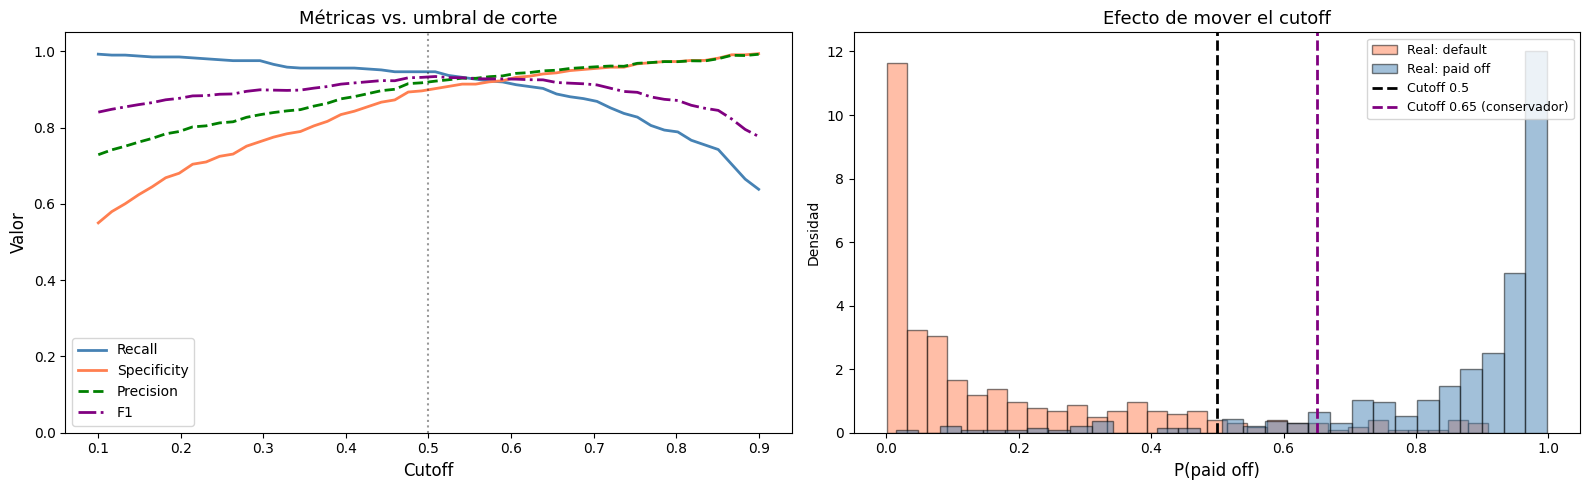

→ El cutoff óptimo depende del costo de cada tipo de error
→ Un banco conservador usaría un cutoff más alto (ej. 0.65)


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Métricas vs cutoff
cutoff_range = np.linspace(0.1, 0.9, 50)
metrics_by_cutoff = [evaluate_at_cutoff(y_test, y_proba_lr, c) for c in cutoff_range]
df_range = pd.DataFrame(metrics_by_cutoff)

for metric, color, ls in [
    ("Recall", "steelblue", "-"),
    ("Specificity", "coral", "-"),
    ("Precision", "green", "--"),
    ("F1", "purple", "-."),
]:
    axes[0].plot(
        df_range["Cutoff"],
        df_range[metric],
        color=color,
        linewidth=2,
        linestyle=ls,
        label=metric,
    )

axes[0].axvline(0.5, color="k", linestyle=":", alpha=0.4)
axes[0].set_xlabel("Cutoff", fontsize=12)
axes[0].set_ylabel("Valor", fontsize=12)
axes[0].set_title("Métricas vs. umbral de corte", fontsize=13)
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 1.05)

# Panel 2: Histograma con dos cutoffs
ax2 = axes[1]
ax2.hist(
    y_proba_lr[mask_default],
    bins=30,
    alpha=0.5,
    color="coral",
    label="Real: default",
    edgecolor="k",
    density=True,
)
ax2.hist(
    y_proba_lr[mask_paid],
    bins=30,
    alpha=0.5,
    color="steelblue",
    label="Real: paid off",
    edgecolor="k",
    density=True,
)
ax2.axvline(0.5, color="k", linestyle="--", linewidth=2, label="Cutoff 0.5")
ax2.axvline(
    0.65, color="purple", linestyle="--", linewidth=2, label="Cutoff 0.65 (conservador)"
)
ax2.set_xlabel("P(paid off)", fontsize=12)
ax2.set_ylabel("Densidad")
ax2.set_title("Efecto de mover el cutoff", fontsize=13)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("→ El cutoff óptimo depende del costo de cada tipo de error")
print("→ Un banco conservador usaría un cutoff más alto (ej. 0.65)")

## 6 · Curva ROC (*ROC Curve*)

La curva ROC traza **Recall** (sensitivity) vs. **1 − Specificity** (tasa de falsos positivos) para **todos los cutoffs posibles**.

- **AUC** (*Area Under the Curve*): resume la curva en un número
  - AUC = 0.5 → modelo aleatorio (diagonal)
  - AUC = 1.0 → modelo perfecto
- La curva permite comparar modelos **sin elegir un cutoff específico**

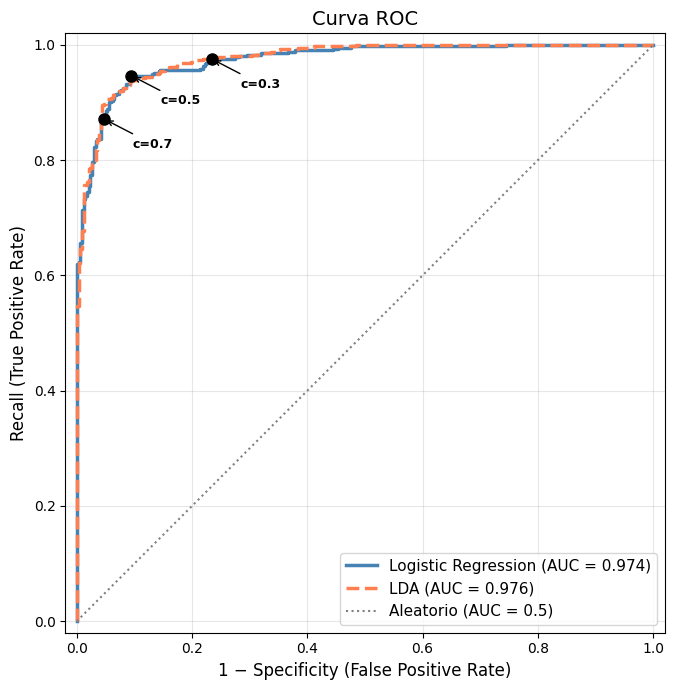

AUC Logistic Regression: 0.974
AUC LDA:                 0.976

→ Ambos modelos tienen AUC similar (~0.97)
→ AUC > 0.9 indica excelente poder discriminativo
→ La curva ROC muestra el tradeoff completo entre recall y specificity


In [34]:
fig, ax = plt.subplots(figsize=(8, 7))

# ROC para ambos modelos
for y_proba, name, color, ls in [
    (y_proba_lr, "Logistic Regression", "steelblue", "-"),
    (y_proba_lda, "LDA", "coral", "--"),
]:
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(
        fpr,
        tpr,
        color=color,
        linewidth=2.5,
        linestyle=ls,
        label=f"{name} (AUC = {auc:.3f})",
    )

    # Anotar cutoffs en la curva de LogReg
    if name == "Logistic Regression":
        for cutoff_val in [0.3, 0.5, 0.7]:
            idx = np.argmin(np.abs(thresholds - cutoff_val))
            ax.plot(fpr[idx], tpr[idx], "o", color="k", markersize=8, zorder=5)
            ax.annotate(
                f"c={cutoff_val}",
                xy=(fpr[idx], tpr[idx]),
                xytext=(fpr[idx] + 0.05, tpr[idx] - 0.05),
                fontsize=9,
                fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="k"),
            )

# Diagonal (aleatorio)
ax.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle=":",
    linewidth=1.5,
    label="Aleatorio (AUC = 0.5)",
)

ax.set_xlabel("1 − Specificity (False Positive Rate)", fontsize=12)
ax.set_ylabel("Recall (True Positive Rate)", fontsize=12)
ax.set_title("Curva ROC", fontsize=14)
ax.legend(loc="lower right", fontsize=11)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

auc_lr = roc_auc_score(y_test, y_proba_lr)
auc_lda = roc_auc_score(y_test, y_proba_lda)
print(f"AUC Logistic Regression: {auc_lr:.3f}")
print(f"AUC LDA:                 {auc_lda:.3f}")
print(f"\n→ Ambos modelos tienen AUC similar (~{auc_lr:.2f})")
print("→ AUC > 0.9 indica excelente poder discriminativo")
print("→ La curva ROC muestra el tradeoff completo entre recall y specificity")

## 7 · Lift — mejora sobre el azar (*Lift*)

El *lift* responde una pregunta práctica:

> Si solo puedo revisar el **20 %** de las solicitudes, ¿cuántos más *paid-offs* capturo con el modelo vs. selección aleatoria?

$$\text{Lift} = \frac{\% \text{ positivos capturados}}{\% \text{ población examinada}}$$

- Lift = 1.0 → igual que el azar
- Lift = 1.8 → capturas 1.8× más que el azar

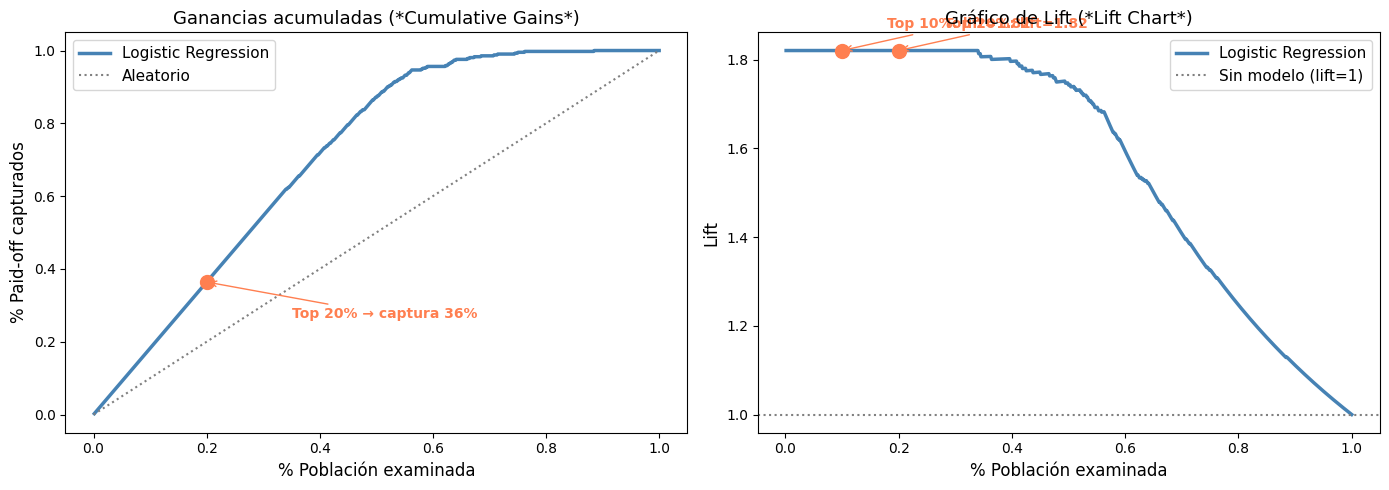

Lift en top 10%: 1.82×
Lift en top 20%: 1.82×

→ Mirando solo el top 20% de la población (los más probables paid-off),
   capturamos ~36% de todos los paid-off reales


In [35]:
# Ordenar por probabilidad descendente
order = np.argsort(-y_proba_lr)
y_sorted = y_test[order]

n = len(y_sorted)
total_positives = y_sorted.sum()

# Acumulados
cum_positives = np.cumsum(y_sorted)
pct_population = np.arange(1, n + 1) / n
pct_captured = cum_positives / total_positives
lift = pct_captured / pct_population

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Cumulative Gains
axes[0].plot(
    pct_population,
    pct_captured,
    color="steelblue",
    linewidth=2.5,
    label="Logistic Regression",
)
axes[0].plot(
    [0, 1], [0, 1], color="gray", linestyle=":", linewidth=1.5, label="Aleatorio"
)
axes[0].set_xlabel("% Población examinada", fontsize=12)
axes[0].set_ylabel("% Paid-off capturados", fontsize=12)
axes[0].set_title("Ganancias acumuladas (*Cumulative Gains*)", fontsize=13)
axes[0].legend(fontsize=11)

# Anotar top 20%
idx_20 = int(0.2 * n)
axes[0].plot(0.2, pct_captured[idx_20 - 1], "o", color="coral", markersize=10, zorder=5)
axes[0].annotate(
    f"Top 20% → captura {pct_captured[idx_20 - 1]:.0%}",
    xy=(0.2, pct_captured[idx_20 - 1]),
    xytext=(0.35, pct_captured[idx_20 - 1] - 0.1),
    fontsize=10,
    color="coral",
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="coral"),
)

# Panel 2: Lift chart
axes[1].plot(
    pct_population, lift, color="steelblue", linewidth=2.5, label="Logistic Regression"
)
axes[1].axhline(
    1, color="gray", linestyle=":", linewidth=1.5, label="Sin modelo (lift=1)"
)
axes[1].set_xlabel("% Población examinada", fontsize=12)
axes[1].set_ylabel("Lift", fontsize=12)
axes[1].set_title("Gráfico de Lift (*Lift Chart*)", fontsize=13)
axes[1].legend(fontsize=11)

# Anotar lift en top 10% y 20%
idx_10 = int(0.1 * n)
for pct, idx, label_pct in [(0.1, idx_10, "10%"), (0.2, idx_20, "20%")]:
    axes[1].plot(pct, lift[idx - 1], "o", color="coral", markersize=10, zorder=5)
    axes[1].annotate(
        f"Top {label_pct}: lift={lift[idx - 1]:.2f}",
        xy=(pct, lift[idx - 1]),
        xytext=(pct + 0.08, lift[idx - 1] + 0.05),
        fontsize=10,
        color="coral",
        fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="coral"),
    )

plt.tight_layout()
plt.show()

print(f"Lift en top 10%: {lift[idx_10 - 1]:.2f}×")
print(f"Lift en top 20%: {lift[idx_20 - 1]:.2f}×")
print(f"\n→ Mirando solo el top 20% de la población (los más probables paid-off),")
print(f"   capturamos ~{pct_captured[idx_20 - 1]:.0%} de todos los paid-off reales")

## 8 · Comparación final (*Model Comparison*)

Juntemos todas las métricas en una tabla y veamos el panorama completo.

In [36]:
def full_metrics(y_true, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Specificity": tn / (tn + fp),
        "F1": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_proba),
    }


summary = pd.DataFrame(
    {
        "Logistic Regression": full_metrics(y_test, y_pred_lr, y_proba_lr),
        "LDA": full_metrics(y_test, y_pred_lda, y_proba_lda),
    }
).T

print("=== Comparación completa ===\n")
print(summary.to_string(float_format=lambda x: f"{x:.3f}"))

=== Comparación completa ===

                     Accuracy  Precision  Recall  Specificity    F1   AUC
Logistic Regression     0.925      0.920   0.947        0.899 0.933 0.974
LDA                     0.912      0.900   0.944        0.873 0.922 0.976


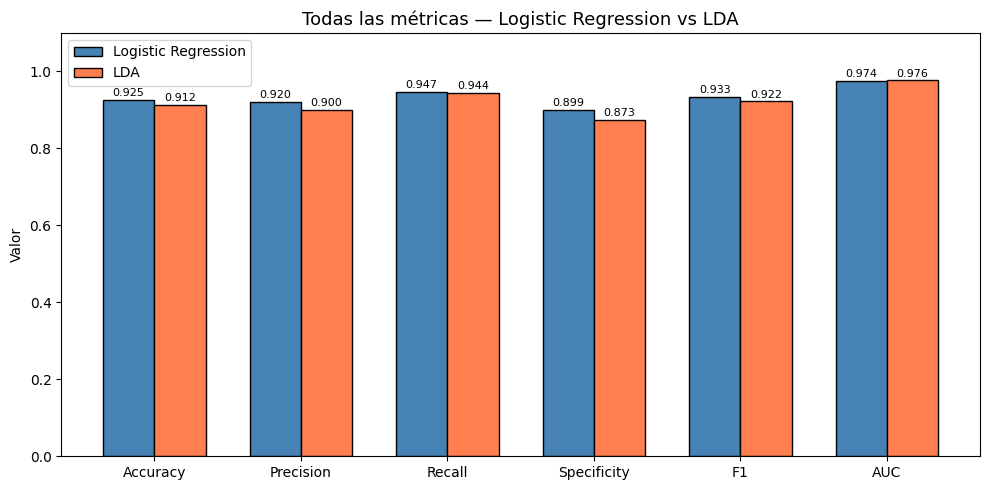

→ Ambos modelos son muy similares en este dataset
→ LogReg tiene una ligera ventaja en accuracy/F1
→ La metodología de evaluación importa más que la elección del modelo

--- classification_report (Logistic Regression) ---
              precision    recall  f1-score   support

     default       0.93      0.90      0.92       338
    paid off       0.92      0.95      0.93       412

    accuracy                           0.93       750
   macro avg       0.93      0.92      0.92       750
weighted avg       0.93      0.93      0.93       750



In [38]:
# Visualización comparativa
fig, ax = plt.subplots(figsize=(10, 5))
metrics_names = summary.columns.tolist()
x_pos = np.arange(len(metrics_names))
width = 0.35

vals_lr = summary.loc["Logistic Regression"].to_numpy()
vals_lda = summary.loc["LDA"].to_numpy()

ax.bar(
    x_pos - width / 2,
    vals_lr,
    width,
    label="Logistic Regression",
    color="steelblue",
    edgecolor="k",
)
ax.bar(x_pos + width / 2, vals_lda, width, label="LDA", color="coral", edgecolor="k")

for i, (v1, v2) in enumerate(zip(vals_lr, vals_lda)):
    ax.text(i - width / 2, v1 + 0.01, f"{v1:.3f}", ha="center", fontsize=8)
    ax.text(i + width / 2, v2 + 0.01, f"{v2:.3f}", ha="center", fontsize=8)

ax.set_xticks(x_pos)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Valor")
ax.set_title("Todas las métricas — Logistic Regression vs LDA", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print("→ Ambos modelos son muy similares en este dataset")
print("→ LogReg tiene una ligera ventaja en accuracy/F1")
print("→ La metodología de evaluación importa más que la elección del modelo")
print("\n--- classification_report (Logistic Regression) ---")
print(classification_report(y_test, y_pred_lr, target_names=CLASSES))

## 9 · Resumen

### Referencia de métricas

| Métrica | Fórmula | Pregunta que responde |
|:--|:-:|:--|
| **Accuracy** | $\frac{TP + TN}{N}$ | ¿Qué porcentaje total acierto? |
| **Precision** | $\frac{TP}{TP + FP}$ | De los que predije positivos, ¿cuántos realmente lo son? |
| **Recall** (*Sensitivity*) | $\frac{TP}{TP + FN}$ | De los positivos reales, ¿cuántos capturé? |
| **Specificity** | $\frac{TN}{TN + FP}$ | De los negativos reales, ¿cuántos identifiqué? |
| **F1 Score** | $2 \cdot \frac{P \times R}{P + R}$ | ¿Balance entre precision y recall? |
| **AUC** | Área bajo ROC | ¿Poder discriminativo general? |
| **Lift** | $\frac{\% capturados}{\% población}$ | ¿Cuánto mejor que el azar? |

### ¿Cuándo priorizar cada métrica?

| Contexto | Métrica prioritaria | Por qué |
|:--|:--|:--|
| Filtro de spam | **Precision** | No quieres marcar emails buenos como spam |
| Detección de cáncer | **Recall** | No quieres dejar pasar un cáncer real |
| Préstamos bancarios | **Specificity** | No quieres aprobar préstamos riesgosos |
| Comparar modelos | **AUC** | Independiente del cutoff elegido |
| Un solo número | **F1** | Resume el tradeoff precision-recall |

### Lecciones clave

1. **Accuracy sola no basta** — siempre revisar la matriz de confusión
2. **El cutoff es una decisión de negocio** — no siempre es 0.5
3. **ROC/AUC** compara modelos sin depender del cutoff
4. **Lift** responde preguntas prácticas: "si solo puedo revisar X%, ¿cuánto gano?"
5. Para este dataset, Logistic Regression y LDA producen resultados muy similares

> 👉 En el siguiente notebook exploraremos **más estrategias de clasificación** y cómo manejar **datos desbalanceados**.